In [102]:
## This notebook is designed to do a few things.
#1. Group ROIs, either true or pred, by connected regions in 2D space.
#2. For each blip in an event:
    #2a. Associate it to a given ROI subset in both truth and reco. Can do this with maximal intersection??
        #Look at all pairwise intersections. For each reco blip, rank true blips by cleanliness*completeness
    #2b. Put in exception handling for un-recoed blips or hallucinations.
    #2c. Integrate True Ar39 signal over true ROI for true energy
    #2d. Integrate Noise+Ar39 signal over pred ROI for reco energy
#. Profit.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label, find_objects
import matplotlib.colors as mcolors

In [2]:
# Group ROIs.

#Load ROIs
# Load memmap files
signal_memmap = np.memmap("/scratch/7DayLifetime/mking/1000_evts_doped/signal.raw", dtype=np.float32, mode='r', shape=(1000, 1280, 2128))
noise_memmap = np.memmap("/scratch/7DayLifetime/mking/1000_evts_doped/noise.raw", dtype=np.float32, mode='r', shape=(1000, 1280, 2128))
roi_memmap = np.load("/scratch/7DayLifetime/mking/1000_evts_doped/roi.npy")  # ROI is loaded directly
roi_pred = np.load("/scratch/7DayLifetime/mking/04_01_2025_1/roi_pred_CNN.npy")  # Predicted ROI from traditional algorithm
roi_pred_no_threshold = np.load("/scratch/7DayLifetime/mking/04_01_2025_1/roi_pred_CNN_no_threshold.npy")
roi_pred_trad = np.load("/scratch/7DayLifetime/mking/1000_evts_doped/roi_pred_trad_4-5_0.npy")

# Extract TPC 0 Plane Z
#noise_data = noise_memmap[:, 800:1040, :]
#signal_data = signal_memmap[:, 800:1040, :]
#roi_data = roi_memmap[:, 800:1040, :]
#Just get training data
noise_data = noise_memmap[850:1000, 800:1040, :2120]
signal_data = signal_memmap[850:1000, 800:1040, :2120]
roi_data = roi_memmap[850:1000, 800:1040, :2120]
roi_pred_trad_data = roi_pred_trad[850:1000, :,:2120]

print(np.shape(noise_data))
print(np.shape(signal_data))
print(np.shape(roi_data))
print(np.shape(roi_pred))

# Assume new_data is the reshaped output with shape (1500, 1, 240, 212)
# We'll now reverse it to get (150, 1, 240, 2120)

# Step 1: Reshape to separate back into (150 events, 10 chunks, 1, 240, 212)
reshaped_back = roi_pred.reshape(150, 10, 240, 212)

# Step 2: Swap axes to bring it to (150, 1, 240, 10, 212)
reshaped_back = reshaped_back.swapaxes(1, 2)

# Step 3: Reshape the last two dimensions back into 2120
roi_pred_comparable = reshaped_back.reshape(150, 240, 2120)
roi_pred_no_threshold_reshaped = roi_pred_no_threshold.reshape(150, 10, 240, 212).swapaxes(1, 2).reshape(150, 240, 2120)

print(np.shape(roi_pred_comparable))
print(np.shape(roi_pred_no_threshold_reshaped))


(150, 240, 2120)
(150, 240, 2120)
(150, 240, 2120)
(1500, 240, 212)
(150, 240, 2120)
(150, 240, 2120)


In [230]:
## First, I ensure that the previous reversal process works on the true ROI
#Forward:
print(np.shape(roi_data))
roi_chunked = roi_data.reshape(150, 240, 10, 212)
roi_reshaped = roi_chunked.swapaxes(1, 2).reshape(1500, 240, 212)

## Now to bring it back
roi_reshaped_back = roi_reshaped.reshape(150, 10, 240, 212).swapaxes(1, 2).reshape(150, 240, 2120)

print(np.array_equal(roi_data,roi_reshaped_back))

(150, 240, 2120)
True


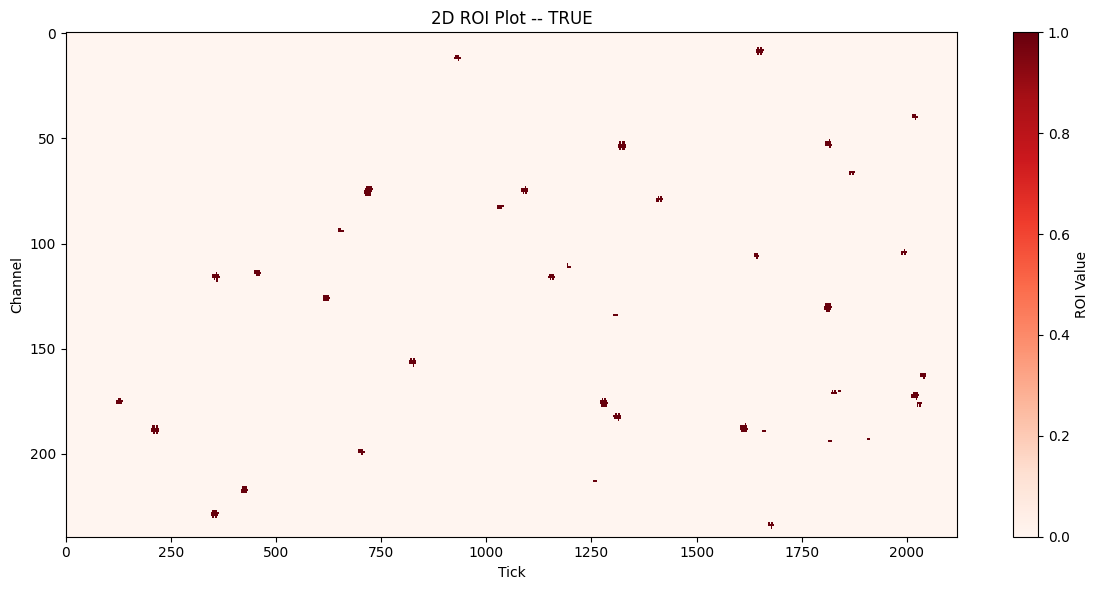

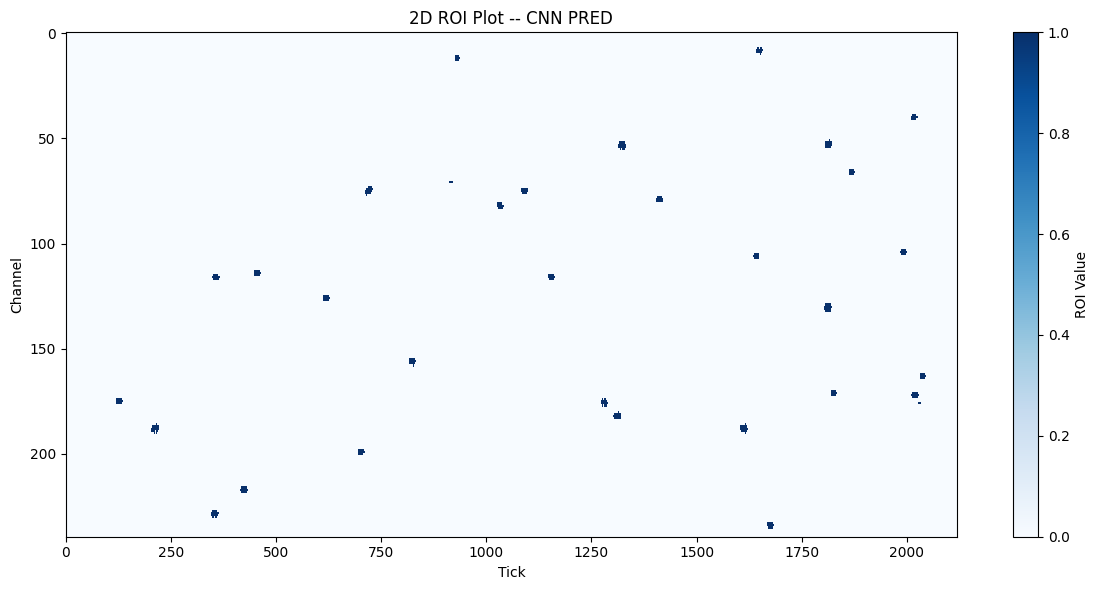

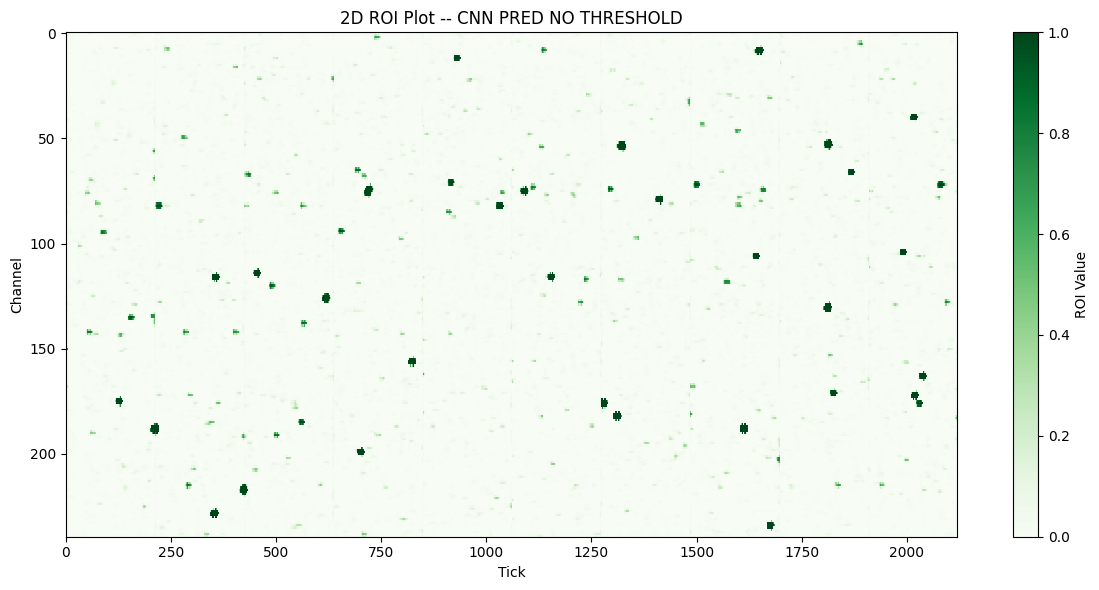

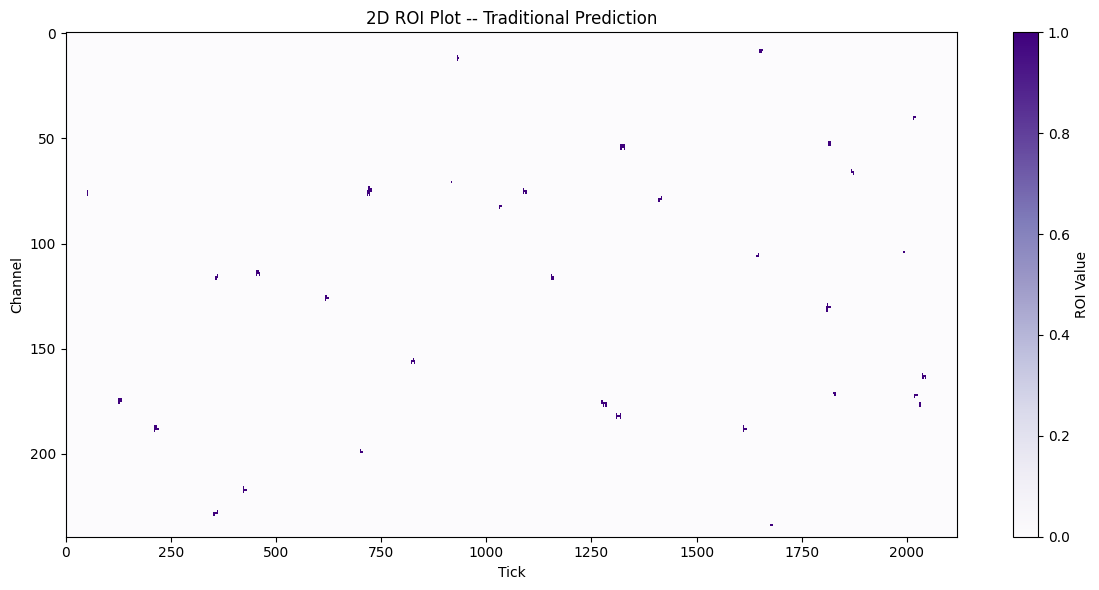

In [231]:
#PLOT ROI matrices

plt.figure(figsize=(12, 6))
plt.imshow(roi_data[0], cmap='Reds', interpolation='nearest', aspect='auto')
plt.colorbar(label='ROI Value')
plt.title("2D ROI Plot -- TRUE")
plt.xlabel("Tick")
plt.ylabel("Channel")
plt.clim(0, 1)  # Ensures 0 is white and 1 is red
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.imshow(roi_pred_comparable[0], cmap='Blues', interpolation='nearest', aspect='auto')
plt.colorbar(label='ROI Value')
plt.title("2D ROI Plot -- CNN PRED")
plt.xlabel("Tick")
plt.ylabel("Channel")
plt.clim(0, 1)  # Ensures 0 is white and 1 is red
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.imshow(roi_pred_no_threshold_reshaped[0], cmap='Greens', interpolation='nearest', aspect='auto')
plt.colorbar(label='ROI Value')
plt.title("2D ROI Plot -- CNN PRED NO THRESHOLD")
plt.xlabel("Tick")
plt.ylabel("Channel")
plt.clim(0, 1)  # Ensures 0 is white and 1 is red
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.imshow(roi_pred_trad_data[0], cmap='Purples', interpolation='nearest', aspect='auto')
plt.colorbar(label='ROI Value')
plt.title("2D ROI Plot -- Traditional Prediction")
plt.xlabel("Tick")
plt.ylabel("Channel")
plt.clim(0, 1)  # Ensures 0 is white and 1 is red
plt.tight_layout()
plt.show()

In [4]:
## Algorithm for one event, then for all 150
## To enumerate the connected events...

def extract_blips(roi_matrix):
    """
    Given a binary ROI matrix of shape (channels, time_ticks), extract blips.
    Returns a list of dictionaries, one per blip.
    """
    # Label connected components (blips)
    structure = np.ones((3, 3))  # 8-connectivity in 2D
    labeled, num_blips = label(roi_matrix, structure=structure)

    blips = []
    for blip_idx in range(1, num_blips + 1):
        # Get mask for this blip
        mask = labeled == blip_idx
        coords = np.argwhere(mask)  # list of (channel, time tick)

        # Compute center and diameter
        ch_min, tt_min = coords.min(axis=0)
        ch_max, tt_max = coords.max(axis=0)
        center = ((ch_min + ch_max) // 2, (tt_min + tt_max) // 2)
        diameter = (ch_max - ch_min + 1, tt_max - tt_min + 1)

        # Store as list of (channel, time tick) pairs
        blips.append({
            'center': center,
            'diameter': diameter,
            'coordinates': coords  # Or coords.tolist() if you need to serialize
        })

    return blips

In [5]:
def plot_blips(blips, title="ROI Blips"):
    """
    Plots a list of blips, each with a different color.
    """
    img = np.zeros((240, 2120))
    for i, blip in enumerate(blips, start=1):
        coords = blip['coordinates']
        img[coords[:, 0], coords[:, 1]] = i  # i will determine color

    num_blips = len(blips)
    cmap = plt.get_cmap('tab20', num_blips)  # Categorical color map

    plt.figure(figsize=(12, 6))
    norm = mcolors.BoundaryNorm(boundaries=np.arange(num_blips+2)-0.5, ncolors=num_blips+1)
    plt.imshow(img, cmap=cmap, norm=norm, interpolation='nearest', aspect='auto')
    plt.colorbar(label='Blip Index')
    plt.title(title)
    plt.xlabel("Tick")
    plt.ylabel("Channel")
    plt.tight_layout()
    plt.show()

In [234]:
true_blips = extract_blips(roi_data[0])
pred_blips = extract_blips(roi_pred_comparable[0])
trad_blips = extract_blips(roi_pred_trad_data[0])

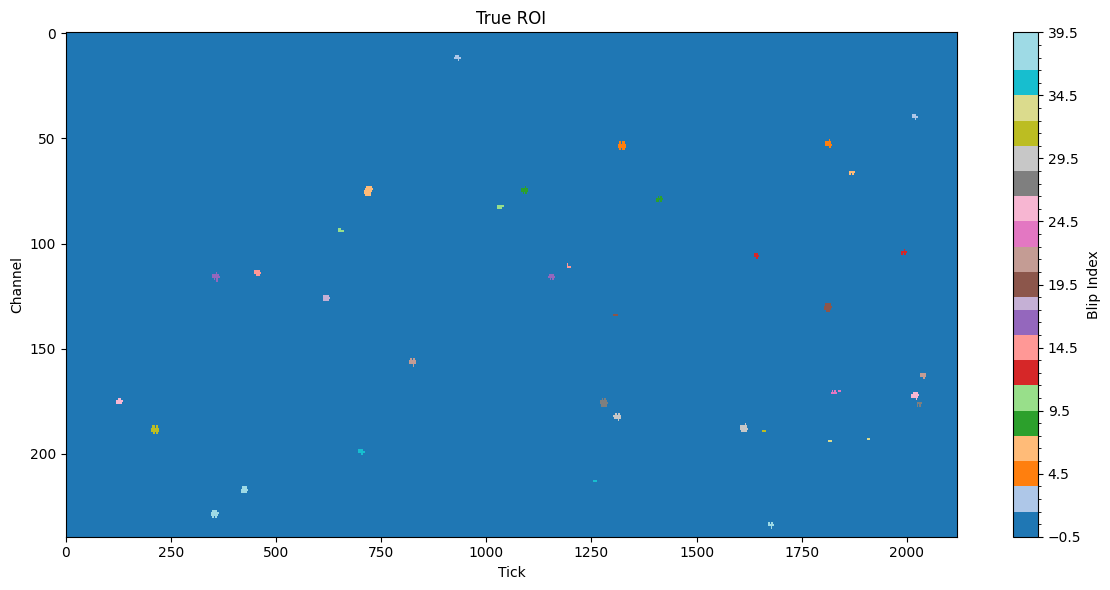

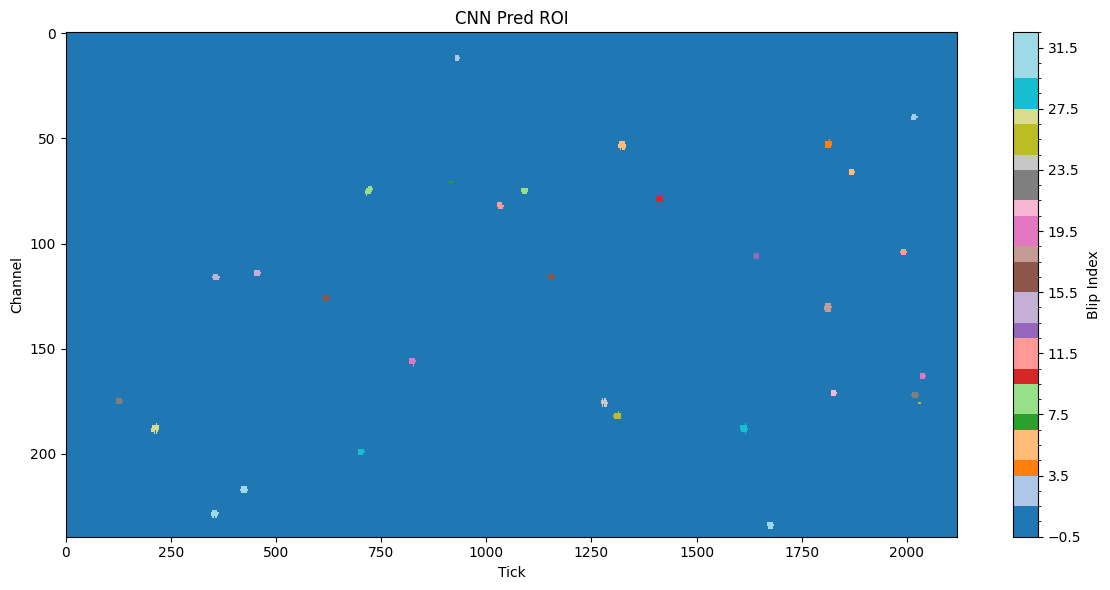

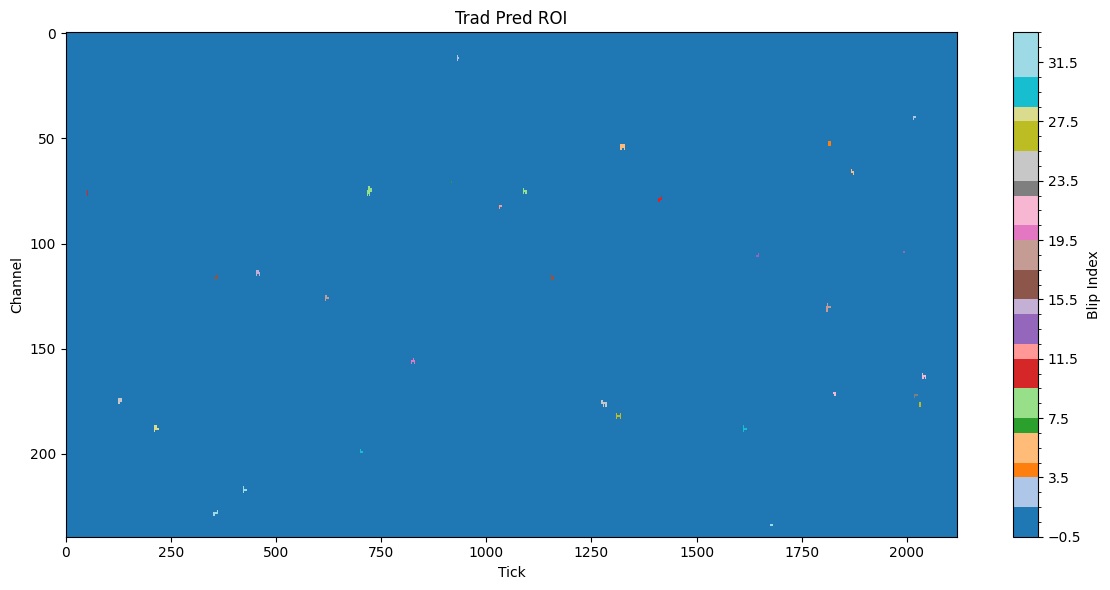

In [235]:
plot_blips(true_blips, title = "True ROI")
plot_blips(pred_blips, title = "CNN Pred ROI")
plot_blips(trad_blips, title = "Trad Pred ROI")

[[   8 1648]
 [  12  930]
 [  40 2016]
 [  52 1812]
 [  53 1320]
 [  66 1867]
 [  75  719]
 [  74 1090]
 [  79 1410]
 [  82 1031]
 [  93  653]
 [ 104 1990]
 [ 106 1640]
 [ 110 1195]
 [ 114  455]
 [ 116  355]
 [ 116 1154]
 [ 126  618]
 [ 130 1811]
 [ 134 1306]
 [ 156  823]
 [ 163 2036]
 [ 170 1825]
 [ 170 1837]
 [ 172 2017]
 [ 175  126]
 [ 175 1278]
 [ 176 2028]
 [ 182 1310]
 [ 187 1611]
 [ 188  211]
 [ 188 1658]
 [ 193 1906]
 [ 194 1815]
 [ 198  701]
 [ 213 1256]
 [ 217  423]
 [ 228  353]
 [ 234 1675]]


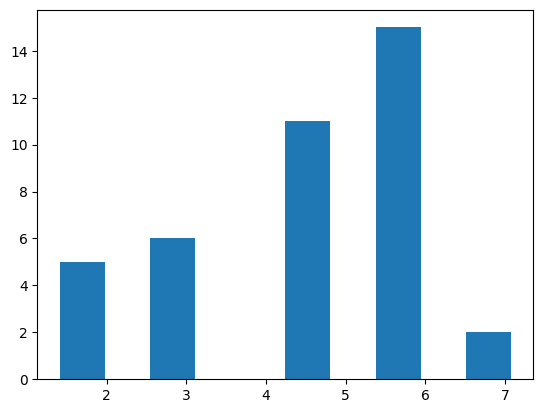

In [236]:
## Verification of sensibility

blip_centers = []
blip_diameters = []

for blip in true_blips:
    blip_centers.append(blip['center'])
    blip_diameters.append((blip['diameter'][0]**2 + blip['diameter'][0]**2)**0.5)

blip_centers=np.array(blip_centers)
blip_diameters=np.array(blip_diameters)

plt.figure()
plt.hist(blip_diameters)

print(blip_centers)
    

In [238]:
true_energies = compute_blip_energies(true_blips, signal_data[0])
reco_energies = compute_blip_energies(pred_blips, noise_data[0])
trad_energies = compute_blip_energies(trad_blips, noise_data[0])

In [6]:
## Energy reconstruction

def compute_blip_energies(blips, signal_array):
    """
    Computes the energy of each blip by summing the signal values at the ROI coordinates.
    
    Returns a list of energies, one per blip.
    """
    energies = []
    for blip in blips:
        coords = blip['coordinates']
        chs, tts = coords[:, 0], coords[:, 1]
        energy = signal_array[chs, tts].sum()
        energies.append(energy)
    return energies


(array([6., 4., 3., 5., 4., 1., 3., 3., 1., 2.]),
 array([ 62.47070312, 129.08366394, 195.69662476, 262.30957031,
        328.92254639, 395.53552246, 462.14846802, 528.76141357,
        595.37438965, 661.98736572, 728.6003418 ]),
 <BarContainer object of 10 artists>)

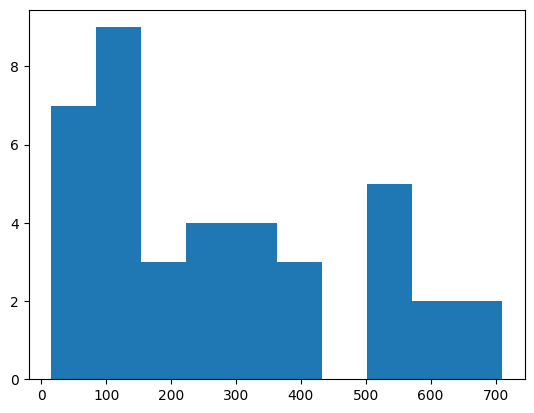

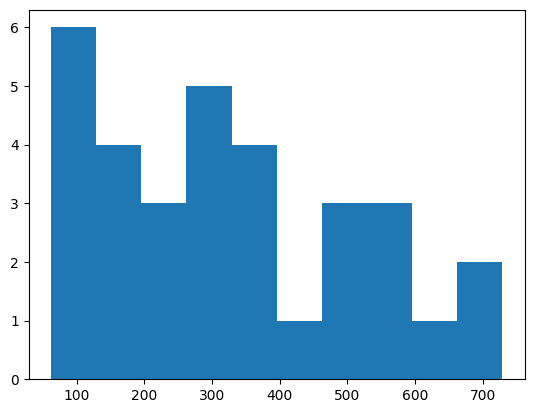

In [239]:
plt.figure()
plt.hist(true_energies)

plt.figure()
plt.hist(reco_energies)

In [240]:
## Now do the blip energy reconstruction for all blips across all events:
true_energies = []
reco_energies = []
trad_energies = [] 

for iEvent in range(150):
    true_blips = extract_blips(roi_data[iEvent])
    pred_blips = extract_blips(roi_pred_comparable[iEvent])
    trad_blips = extract_blips(roi_pred_trad_data[iEvent])

    true_energies = [*true_energies, *compute_blip_energies(true_blips, signal_data[iEvent])]
    reco_energies = [*reco_energies, *compute_blip_energies(pred_blips, noise_data[iEvent])]
    trad_energies = [*trad_energies, *compute_blip_energies(trad_blips, noise_data[iEvent])]

In [241]:
print(max(true_energies))
print(max(reco_energies))

1135.0
1231.4575


In [7]:
def plot_energy_comparison(true_energies, pred_energies, trad_energies, bins=30, log_scale=False):
    """
    Plots an overlaid histogram comparing true and predicted blip energies.
    """
    plt.figure(figsize=(10, 6))

    plt.hist(true_energies, bins=bins, alpha=0.6, color='blue', label='True Blip Energies', histtype='step')
    plt.hist(pred_energies, bins=bins, alpha=0.6, color='orange', label='CNN Predicted Blip Energies', histtype='step')
    plt.hist(trad_energies, bins=bins, alpha=0.6, color='green', label='Traditional Predicted Blip Energies', histtype='step')

    plt.title("Blip Energy Distribution: True vs Predicted")
    plt.xlabel("Energy (ADC*timetick)")
    plt.ylabel("Number of Blips")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    ## add residuals underneath
    
    if log_scale:
        plt.yscale('log')

    plt.tight_layout()
    plt.show()

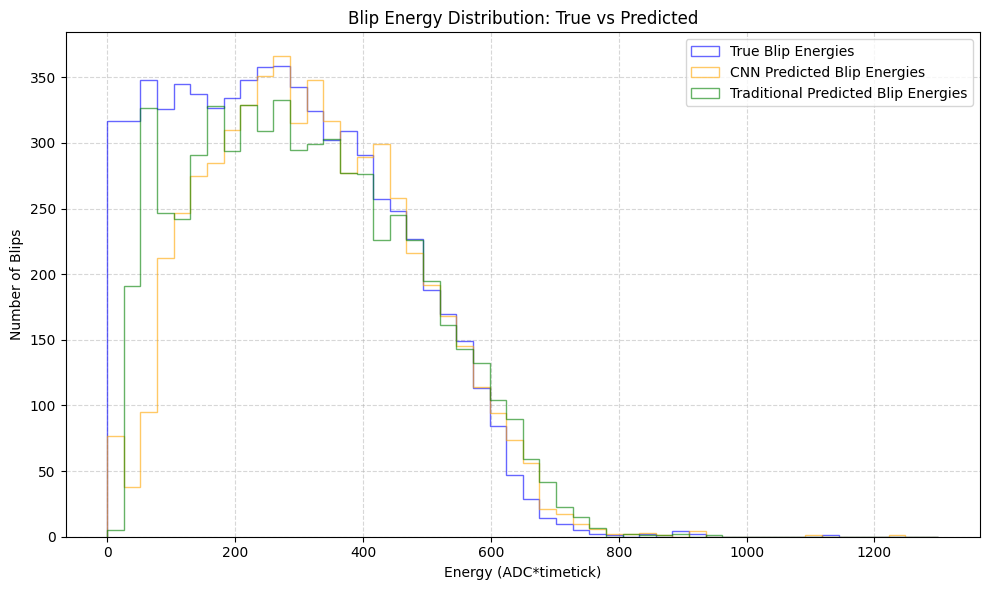

In [243]:
plot_energy_comparison(true_energies, reco_energies, trad_energies, bins=np.linspace(0,1300,51))

In [8]:
def match_blips(pred_blips, true_blips):
    """
    Match each predicted blip to the true blip with highest precision * recall.
    Returns a list of tuples: (pred_idx, true_idx, precision, recall, score)
    """
    matches = []

    for pred_idx, pred in enumerate(pred_blips):
        pred_coords = set(map(tuple, pred['coordinates']))
        best_match = None
        best_score = 0

        for true_idx, true in enumerate(true_blips):
            true_coords = set(map(tuple, true['coordinates']))
            intersection = pred_coords & true_coords
            if not intersection:
                continue

            precision = len(intersection) / len(pred_coords)
            recall = len(intersection) / len(true_coords)
            score = precision * recall

            if score > best_score:
                best_score = score
                best_match = (pred_idx, true_idx, precision, recall, score)

        if best_match:
            matches.append(best_match)

    return matches

In [245]:
## Next truth-match blips.
## Get idea of efficiency and purity for blip ROI as a function of true energy
## 2D plot of true vs. reco energy for blips

## Also need to implement this for trad alg after improving trad alg to include 2D info
#Look at number of hallucinated blips - can use to help tune s_high and s_low

true_blips = extract_blips(roi_data[0])
pred_blips = extract_blips(roi_pred_comparable[0])
trad_blips = extract_blips(roi_pred_trad_data[0])

matches = match_blips(pred_blips,true_blips)

In [9]:
def evaluate_blip_matching(true_blips, pred_blips, matches):
    matched_true_idxs = set(match[1] for match in matches)
    matched_pred_idxs = set(match[0] for match in matches)

    TP = len(matches)
    FP = len(pred_blips) - TP  # hallucinated
    FN = len(true_blips) - TP  # missed

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"True Positives: {TP}")
    print(f"False Positives (Hallucinated): {FP}")
    print(f"False Negatives (Missed): {FN}")
    print(f"Precision: {precision:.3f}, Recall: {recall:.3f}, F1 Score: {f1:.3f}")

    return TP, FP, FN, precision, recall, f1

In [10]:
def get_missed_and_hallucinated(true_blips, pred_blips, matches):
    matched_true_indices = set(match[1] for match in matches)
    matched_pred_indices = set(match[0] for match in matches)

    missed_true_indices = [i for i in range(len(true_blips)) if i not in matched_true_indices]
    hallucinated_pred_indices = [i for i in range(len(pred_blips)) if i not in matched_pred_indices]

    return missed_true_indices, hallucinated_pred_indices

In [11]:
def plot_blip_energies_by_indices(energies, indices, title="Blip Energy Distribution"):
    """
    Plots the energies of a subset of blips using precomputed energies from signal_array.

    Parameters:
        blips: list of blip dicts (each with 'coordinates')
        indices: list of int — indices of blips to include
        signal_array: 2D numpy array (channels x ticks)
        title: str — plot title
    """
    selected_energies = [energies[i] for i in indices]

    plt.figure(figsize=(8, 4))
    plt.hist(selected_energies, bins=30, color='darkorange', histtype='step')
    plt.title(title)
    plt.xlabel("Energy (ADC or charge)")
    plt.ylabel("Number of Blips")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    return selected_energies

In [12]:
def compute_energy_residuals(matches, true_blips, pred_blips, true_signal, noise):
    e_true = []
    e_pred = []
    residuals = []

    for pred_idx, true_idx, _, _, _ in matches:
        coords_true = true_blips[true_idx]['coordinates']
        coords_pred = pred_blips[pred_idx]['coordinates']

        energy_true = true_signal[coords_true[:, 0], coords_true[:, 1]].sum()
        energy_pred = noise[coords_pred[:, 0], coords_pred[:, 1]].sum()

        e_true.append(energy_true)
        e_pred.append(energy_pred)

        if energy_true > 0:
            residuals.append((energy_pred - energy_true) / energy_true)

    return np.array(e_true), np.array(e_pred), np.array(residuals)

In [13]:
def plot_spatial_offset(matches, true_blips, pred_blips):
    offsets = []
    for pred_idx, true_idx, _, _, _ in matches:
        c_pred, t_pred = pred_blips[pred_idx]['center']
        c_true, t_true = true_blips[true_idx]['center']
        offset = np.sqrt((c_pred - c_true)**2 + (t_pred - t_true)**2)
        offsets.append(offset)

    plt.figure(figsize=(8, 4))
    plt.hist(offsets, bins=30, color='teal', edgecolor='black')
    plt.title("Spatial Offset Between Matched Blips")
    plt.xlabel("Euclidean Distance (Channel-Tick)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [14]:
def plot_energy_scatter(e_true, e_pred):
    plt.figure(figsize=(6, 6))
    plt.hist2d(e_true, e_pred, bins=50, cmap='viridis', norm='log')
    #plt.plot([min(e_true), max(e_true)], [min(e_true), max(e_true)], 'r--')
    plt.plot(np.linspace(min(e_true),max(e_true),50),np.linspace(min(e_true),max(e_true),50),'r--')
    plt.xlabel("True Energy")
    plt.ylabel("Predicted Energy")
    plt.title("True vs Predicted Blip Energy")
    plt.colorbar(label='Blip Count')
    plt.tight_layout()
    plt.show()

def plot_residual_hist(residuals):
    plt.figure(figsize=(8, 4))
    plt.hist(residuals, bins=40, color='purple', edgecolor='k')
    plt.axvline(0, color='red', linestyle='--', label='Zero Bias')
    plt.title("Relative Energy Residuals: (Pred - True) / True")
    plt.xlabel("Relative Residual")
    plt.ylabel("Number of Blips")
    plt.legend()
    plt.tight_layout()
    plt.show()

def print_energy_resolution(residuals):
    bias = np.mean(residuals)
    resolution = np.std(residuals)
    print(f"Energy Bias (mean residual): {bias:.3f}")
    print(f"Energy Resolution (std of residuals): {resolution:.3f}")

In [15]:
def plot_blip_size_scatter(matches, true_blips, pred_blips):
    true_sizes = []
    pred_sizes = []

    for pred_idx, true_idx, _, _, _ in matches:
        true_sizes.append(len(true_blips[true_idx]['coordinates']))
        pred_sizes.append(len(pred_blips[pred_idx]['coordinates']))

    plt.figure(figsize=(6, 6))
    plt.hist2d(true_sizes, pred_sizes, bins=40, cmap='plasma', norm='log')
    plt.plot([0, max(true_sizes)], [0, max(true_sizes)], 'r--')
    plt.xlabel("True Blip Size (pixels)")
    plt.ylabel("Predicted Blip Size (pixels)")
    plt.title("True vs Predicted Blip Sizes")
    plt.colorbar(label='Blip Count')
    plt.tight_layout()
    plt.show()

In [16]:
def compute_pixel_overlap_metrics(matches, true_blips, pred_blips):
    overlap_metrics = []

    for pred_idx, true_idx, _, _, _ in matches:
        coords_true = set(map(tuple, true_blips[true_idx]['coordinates']))
        coords_pred = set(map(tuple, pred_blips[pred_idx]['coordinates']))

        TP = len(coords_true & coords_pred)
        FP = len(coords_pred - coords_true)
        FN = len(coords_true - coords_pred)

        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall    = TP / (TP + FN) if (TP + FN) > 0 else 0

        overlap_metrics.append({
            'true_idx': true_idx,
            'pred_idx': pred_idx,
            'TP': TP,
            'FP': FP,
            'FN': FN,
            'precision': precision,
            'recall': recall
        })

    return overlap_metrics

True Positives: 31
False Positives (Hallucinated): 1
False Negatives (Missed): 8
Precision: 0.969, Recall: 0.795, F1 Score: 0.873


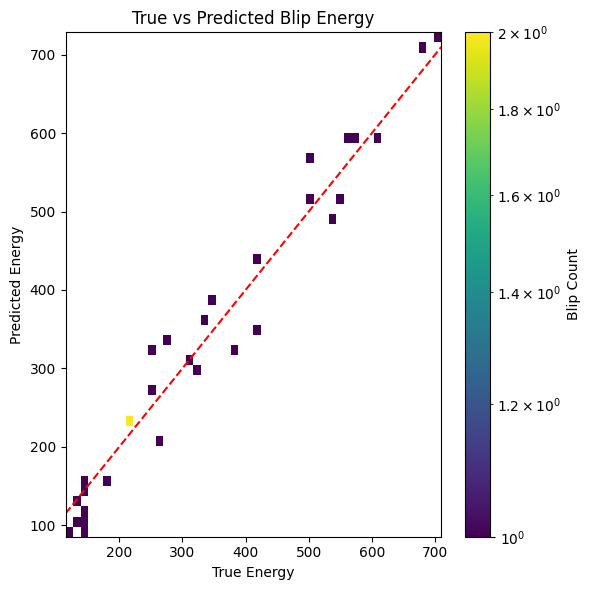

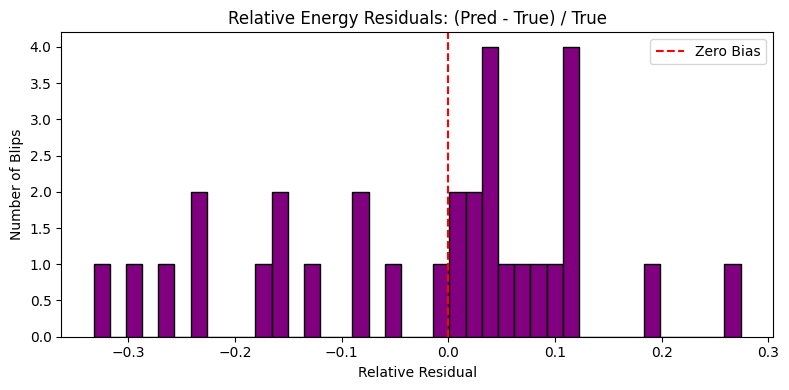

Energy Bias (mean residual): -0.024
Energy Resolution (std of residuals): 0.145


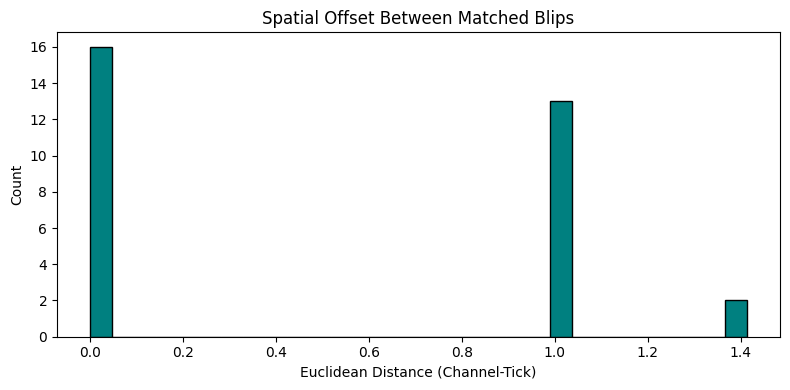

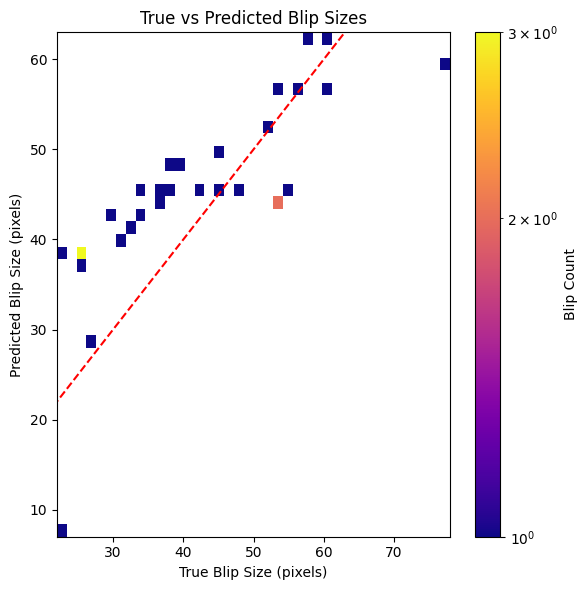

Match: True 0 ↔ Pred 0
  TP: 43, FP: 1, FN: 11
  Precision: 0.977, Recall: 0.796
Match: True 1 ↔ Pred 1
  TP: 23, FP: 6, FN: 4
  Precision: 0.793, Recall: 0.852
Match: True 2 ↔ Pred 2
  TP: 26, FP: 12, FN: 0
  Precision: 0.684, Recall: 1.000
Match: True 3 ↔ Pred 3
  TP: 37, FP: 11, FN: 1
  Precision: 0.771, Recall: 0.974
Match: True 4 ↔ Pred 4
  TP: 60, FP: 3, FN: 1
  Precision: 0.952, Recall: 0.984


In [254]:
## For CNN Pred Blips
TP, FP, FN, precision, recall, f1 = evaluate_blip_matching(true_blips, pred_blips, matches)

e_true, e_pred, residuals = compute_energy_residuals(matches, true_blips, pred_blips, signal_data[0], noise_data[0])

missed_true_indices, hallucinated_pred_indices = get_missed_and_hallucinated(true_blips, pred_blips, matches)
#plot_blip_energies_by_indices(energies, indices, title="Blip Energy Distribution"):

plot_energy_scatter(e_true, e_pred)
plot_residual_hist(residuals)
print_energy_resolution(residuals)
plot_spatial_offset(matches, true_blips, pred_blips)
plot_blip_size_scatter(matches, true_blips, pred_blips)
overlap_stats = compute_pixel_overlap_metrics(matches, true_blips, pred_blips)
for stat in overlap_stats[:5]:
    print(f"Match: True {stat['true_idx']} ↔ Pred {stat['pred_idx']}")
    print(f"  TP: {stat['TP']}, FP: {stat['FP']}, FN: {stat['FN']}")
    print(f"  Precision: {stat['precision']:.3f}, Recall: {stat['recall']:.3f}")

## Plot energy histogram for missed true blips and hallucinated reco blips


True Positives: 31
False Positives (Hallucinated): 2
False Negatives (Missed): 8
Precision: 0.939, Recall: 0.795, F1 Score: 0.861


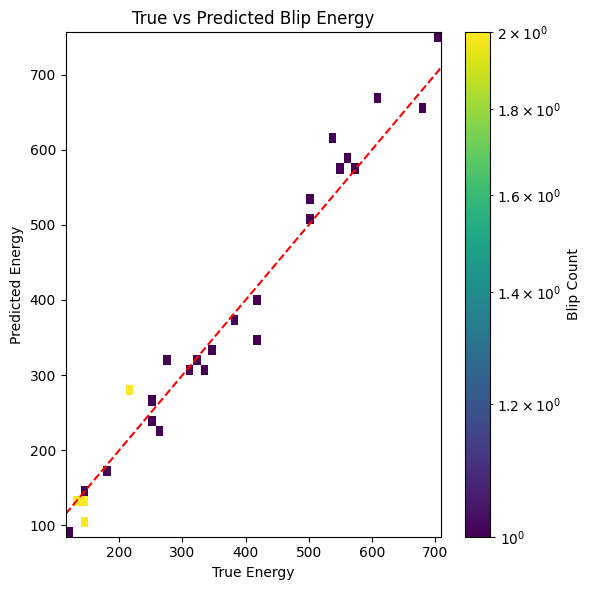

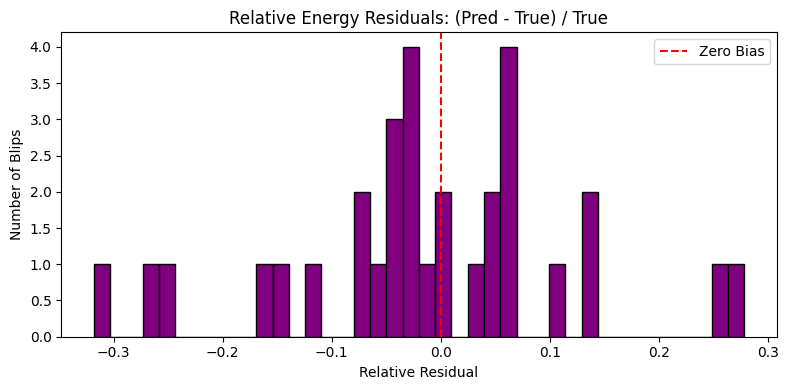

Energy Bias (mean residual): -0.014
Energy Resolution (std of residuals): 0.130


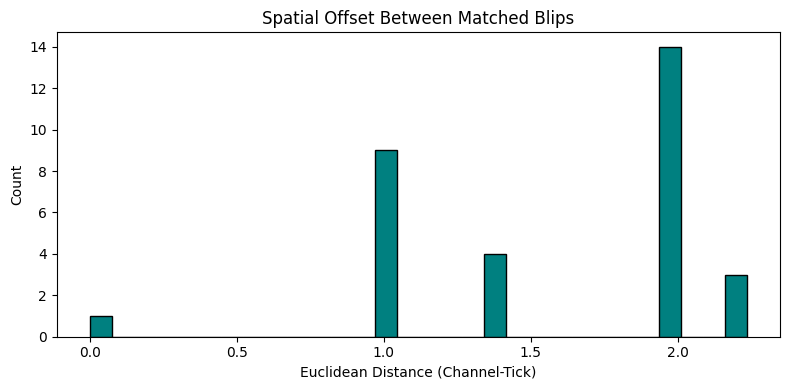

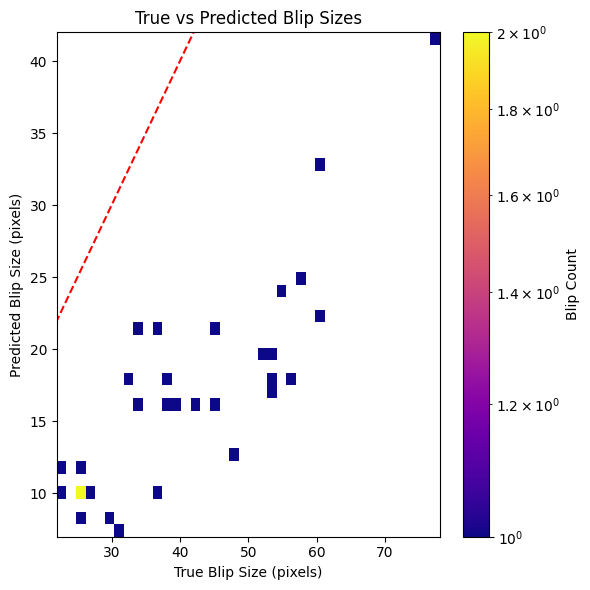

Match: True 0 ↔ Pred 0
  TP: 17, FP: 0, FN: 37
  Precision: 1.000, Recall: 0.315
Match: True 1 ↔ Pred 1
  TP: 7, FP: 3, FN: 20
  Precision: 0.700, Recall: 0.259
Match: True 2 ↔ Pred 2
  TP: 7, FP: 3, FN: 19
  Precision: 0.700, Recall: 0.269
Match: True 3 ↔ Pred 3
  TP: 16, FP: 2, FN: 22
  Precision: 0.889, Recall: 0.421
Match: True 4 ↔ Pred 4
  TP: 31, FP: 2, FN: 30
  Precision: 0.939, Recall: 0.508


In [255]:
## For Trad Pred Blips
matches_trad = match_blips(trad_blips,true_blips)

TP, FP, FN, precision, recall, f1 = evaluate_blip_matching(true_blips, trad_blips, matches_trad)

e_true, e_pred, residuals = compute_energy_residuals(matches_trad, true_blips, trad_blips, signal_data[0], noise_data[0])

plot_energy_scatter(e_true, e_pred)
plot_residual_hist(residuals)
print_energy_resolution(residuals)
plot_spatial_offset(matches_trad, true_blips, trad_blips)
plot_blip_size_scatter(matches_trad, true_blips, trad_blips)
overlap_stats = compute_pixel_overlap_metrics(matches_trad, true_blips, trad_blips)
for stat in overlap_stats[:5]:
    print(f"Match: True {stat['true_idx']} ↔ Pred {stat['pred_idx']}")
    print(f"  TP: {stat['TP']}, FP: {stat['FP']}, FN: {stat['FN']}")
    print(f"  Precision: {stat['precision']:.3f}, Recall: {stat['recall']:.3f}")

## Plot energy histogram for missed true blips and hallucinated reco blips

In [ ]:
## Multi-event pipeline:

In [37]:
def evaluate_blip_detection_across_events(true_roi_array, pred_trad_array, pred_cnn_array, true_signal_array, noise_signal_array):
    """
        Evaluate blip detection across all events for both traditional and CNN predictions.
    
    Inputs:
        true_roi_array: large stacked numpy arrays of shape (n_events, 240, 2120) true ROI masks
        pred_trad_array: large stacked numpy arrays of shape (n_events, 240, 2120) traditional predicted ROI masks
        pred_cnn_array: large stacked numpy arrays of shape (n_events, 240, 2120) CNN predicted ROI masks
        true_signal_array: large stacked numpy arrays of shape (n_events, 240, 2120) true Ar39 waveforms
        noise_signal_array: large stacked numpy arrays of shape (n_events, 240, 2120) noise plus Ar39 waveforms
    
    Returns:
        results: dict containing evaluation stats per method, per event

    """
    from collections import defaultdict

    n_events = true_roi_array.shape[0]
    results = defaultdict(list)

    for i in range(n_events):
        print(i)
        true_roi = true_roi_array[i]
        pred_trad = pred_trad_array[i]
        pred_cnn = pred_cnn_array[i]
        true_signal = true_signal_array[i]
        noise_signal = noise_signal_array[i]

        true_blips = extract_blips(true_roi)
        trad_blips = extract_blips(pred_trad)
        cnn_blips = extract_blips(pred_cnn)

        true_energies = compute_blip_energies(true_blips, true_signal)
        trad_energies = compute_blip_energies(trad_blips, noise_signal)
        cnn_energies = compute_blip_energies(cnn_blips, noise_signal)

        trad_matches = match_blips(trad_blips, true_blips)
        cnn_matches  = match_blips(cnn_blips, true_blips)

        trad_missed, trad_halluc = get_missed_and_hallucinated(true_blips, trad_blips, trad_matches)
        cnn_missed, cnn_halluc   = get_missed_and_hallucinated(true_blips, cnn_blips, cnn_matches)

        trad_overlap = compute_pixel_overlap_metrics(trad_matches, true_blips, trad_blips)
        cnn_overlap  = compute_pixel_overlap_metrics(cnn_matches, true_blips, cnn_blips)

        results['event'].append(i)
        results['true_blips'].append(true_blips)
        results['true_energies'].append(true_energies)

        for method, blips, matches, missed, halluc, energies, overlap in [
            ('trad', trad_blips, trad_matches, trad_missed, trad_halluc, trad_energies, trad_overlap),
            ('cnn', cnn_blips, cnn_matches, cnn_missed, cnn_halluc, cnn_energies, cnn_overlap),
        ]:
            results[f'{method}_blips'].append(blips)
            results[f'{method}_matched'].append(matches)
            results[f'{method}_missed'].append(missed)
            results[f'{method}_hallucinated'].append(halluc)
            results[f'{method}_energies'].append(energies)
            results[f'{method}_overlap'].append(overlap)

    return results

In [38]:
results = evaluate_blip_detection_across_events(
    true_roi_array=roi_data,
    pred_trad_array=roi_pred_trad_data,
    pred_cnn_array=roi_pred_comparable,
    true_signal_array=signal_data,
    noise_signal_array=noise_data
)
# Noise + Ar39: noise_data
#Ar39 true: signal_data
#True ROI: roi_data
#Trad Pred ROI: roi_pred_trad_data
#CNN Pred ROI: roi_pred_comparable 



0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149


In [26]:
methods = ['trad', 'cnn']
for method in methods:
    #print(results[f'{method}_blips'][0])
    #print(results[f'{method}_matched'][0])
    print(results[f'{method}_missed'][0])
    #print(results[f'{method}_hallucinated'][0])
    #print(results[f'{method}_energies'][0])
    #print(results[f'{method}_overlap'][0])

#For each event,
#results["cnn_blips"][iEvent] is a list of Python dictionaries with [center],[diameter],[coordinates]
    #results["cnn_blips"][iEvent][iBlip]["coordinates"][iCoord][channel][timetick]
#results["cnn_matched"][iEvent][iBlip][iItem] Items: (pred_idx, true_idx, precision, recall, score)
#results["cnn_missed"][iEvent][iTrueIdx]
#results["cnn_hallucinated"][iEvent][iPredIdx]
#results["cnn_energies"][iEvent][iBlipEnergy]
#results["cnn_overlap"][iEvent][iMatch]["dict item"] items:'true_idx', 'pred_idx', TP, FP, FN, precision, recall


[10, 13, 19, 23, 31, 32, 33, 35]
[10, 13, 19, 23, 31, 32, 33, 35]


In [46]:
import numpy as np
import matplotlib.pyplot as plt

def plot_blip_evaluation_diagnostics(results):
    methods = ['trad', 'cnn']

    for method in methods:
        all_true_energy, all_pred_energy = [], []
        delta_channels, delta_ticks = [], []
        true_sizes, pred_sizes = [], []
        all_tp, all_fp, all_fn = [], [], []

        # --- 1. Histogram of fraction of true blips missed per event ---
        missed_counts = [len(missed) for missed in results[f'{method}_missed']]
        total_true_blips = [len(blips) for blips in results['true_blips']]
        missed_fraction = np.array(missed_counts) / np.maximum(total_true_blips, 1)

        plt.figure(figsize=(10, 4))
        plt.hist(missed_fraction, bins=20, alpha=0.7, color='orange')
        plt.title(f'{method.upper()} - Fraction of Missed Blips per Event')
        plt.xlabel('Fraction Missed')
        plt.ylabel('Number of Events')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # --- 2. Histogram of hallucinated blips (as fraction of pred blips) ---
        hallucinated_counts = [len(halluc) for halluc in results[f'{method}_hallucinated']]
        total_pred_blips = [len(blips) for blips in results[f'{method}_blips']]
        hallucinated_fraction = np.array(hallucinated_counts) / np.maximum(total_pred_blips, 1)

        plt.figure(figsize=(10, 4))
        plt.hist(hallucinated_fraction, bins=20, alpha=0.7, color='blue')
        plt.title(f'{method.upper()} - Fraction of Hallucinated Blips per Event')
        plt.xlabel('Fraction Hallucinated')
        plt.ylabel('Number of Events')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # --- 3. Histogram of energy of missed blips ---
        missed_energies = []
        for i_event, missed_indices in enumerate(results[f'{method}_missed']):
            true_energies = results['true_energies'][i_event]
            for idx in missed_indices:
                missed_energies.append(true_energies[idx])

        plt.figure(figsize=(10, 4))
        plt.hist(missed_energies, bins=30, alpha=0.7, color='darkorange')
        plt.title(f'{method.upper()} - Energy of Missed Blips')
        plt.xlabel('True Energy')
        plt.ylabel('Count')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # --- 4. Histogram of energy of hallucinated blips ---
        hallucinated_energies = []
        for i_event, halluc_indices in enumerate(results[f'{method}_hallucinated']):
            pred_energies = results[f'{method}_energies'][i_event]
            for idx in halluc_indices:
                hallucinated_energies.append(pred_energies[idx])

        plt.figure(figsize=(10, 4))
        plt.hist(hallucinated_energies, bins=30, alpha=0.7, color='steelblue')
        plt.title(f'{method.upper()} - Energy of Hallucinated Blips')
        plt.xlabel('Predicted Energy')
        plt.ylabel('Count')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # --- 5. Histogram of precision, recall, and score for matched blips ---
        precision_list = []
        recall_list = []
        score_list = []

        for match_list in results[f'{method}_matched']:
            for match in match_list:
                _, _, precision, recall, score = match
                precision_list.append(precision)
                recall_list.append(recall)
                score_list.append(score)

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.hist(precision_list, bins=20, alpha=0.7, color='green')
        plt.title(f'{method.upper()} Precision (Matched Blips)')
        plt.xlabel('Precision')
        plt.ylabel('Count')

        plt.subplot(1, 3, 2)
        plt.hist(recall_list, bins=20, alpha=0.7, color='purple')
        plt.title(f'{method.upper()} Recall (Matched Blips)')
        plt.xlabel('Recall')
        plt.ylabel('Count')

        plt.subplot(1, 3, 3)
        plt.hist(score_list, bins=20, alpha=0.7, color='gray')
        plt.title(f'{method.upper()} Score (Precision × Recall)')
        plt.xlabel('Score')
        plt.ylabel('Count')

        plt.tight_layout()
        plt.show()

        # --- 6. Energy Scatter Plot: True vs Reco ---
        for i_event, matches in enumerate(results[f'{method}_matched']):
            true_blips = results['true_blips'][i_event]
            pred_blips = results[f'{method}_blips'][i_event]
            true_energies = results['true_energies'][i_event]
            pred_energies = results[f'{method}_energies'][i_event]
            overlap_info = results[f'{method}_overlap'][i_event]

            for m_idx, match in enumerate(matches):
                pred_idx, true_idx, precision, recall, score = match

                all_true_energy.append(true_energies[true_idx])
                all_pred_energy.append(pred_energies[pred_idx])

                pred_center = pred_blips[pred_idx]['center']
                true_center = true_blips[true_idx]['center']
                delta = np.array(pred_center) - np.array(true_center)
                delta_channels.append(delta[0])
                delta_ticks.append(delta[1])

                pred_size = pred_blips[pred_idx]['diameter']
                true_size = true_blips[true_idx]['diameter']
                pred_sizes.append((pred_size[0]**2 + pred_size[0]**2)**0.5)
                true_sizes.append((true_size[0]**2 + true_size[0]**2)**0.5)

                tp = overlap_info[m_idx]['TP']
                fp = overlap_info[m_idx]['FP']
                fn = overlap_info[m_idx]['FN']
                all_tp.append(tp)
                all_fp.append(fp)
                all_fn.append(fn)

        plt.figure(figsize=(6, 6))
        plt.scatter(all_true_energy, all_pred_energy, alpha=0.4, s=10)
        max_e = max(max(all_true_energy), max(all_pred_energy), 1)
        plt.plot([0, max_e], [0, max_e], 'r--')
        plt.title(f'{method.upper()} Matched Blip Energy')
        plt.xlabel('True Energy')
        plt.ylabel('Reco Energy')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # --- 7. Spatial Offset Scatter Plot ---
        plt.figure(figsize=(6, 6))
        plt.scatter(delta_channels, delta_ticks, alpha=0.5, s=10)
        plt.axhline(0, color='gray', linestyle='--')
        plt.axvline(0, color='gray', linestyle='--')
        plt.title(f'{method.upper()} Spatial Offset (Pred - True)')
        plt.xlabel('Δ Channel')
        plt.ylabel('Δ Tick')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # --- 8. Blip Size Comparison ---
        plt.figure(figsize=(6, 6))
        plt.scatter(true_sizes, pred_sizes, alpha=0.5, s=10)
        max_size = max(max(true_sizes), max(pred_sizes), 1)
        plt.plot([0, max_size], [0, max_size], 'r--')
        plt.title(f'{method.upper()} Blip Size Comparison')
        plt.xlabel('True Diameter')
        plt.ylabel('Reco Diameter')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # --- 9. Pixel-Level Overlap Metrics ---
        plt.figure(figsize=(10, 4))
        plt.hist(all_tp, bins=30, alpha=0.7, label='TP', color='green')
        plt.hist(all_fp, bins=30, alpha=0.7, label='FP', color='red')
        plt.hist(all_fn, bins=30, alpha=0.7, label='FN', color='blue')
        plt.title(f'{method.upper()} Pixel-Level Overlap')
        plt.xlabel("Pixel Count")
        plt.ylabel("Frequency")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [50]:
import numpy as np
import matplotlib.pyplot as plt

def plot_blip_evaluation_diagnostics(results):
    methods = ['trad', 'cnn']
    colors = {'trad': 'orange', 'cnn': 'blue'}

    def collect_metrics():
        metrics = {m: {
            'missed_frac': [],
            'halluc_frac': [],
            'missed_energy': [],
            'halluc_energy': [],
            'precision': [],
            'recall': [],
            'score': [],
            'true_energy': [],
            'pred_energy': [],
            'delta_channels': [],
            'delta_ticks': [],
            'true_sizes': [],
            'pred_sizes': [],
            'tp': [],
            'fp': [],
            'fn': [],
        } for m in methods}

        for method in methods:
            for i_event, matches in enumerate(results[f'{method}_matched']):
                true_blips = results['true_blips'][i_event]
                pred_blips = results[f'{method}_blips'][i_event]
                true_energies = results['true_energies'][i_event]
                pred_energies = results[f'{method}_energies'][i_event]
                overlap_info = results[f'{method}_overlap'][i_event]

                for m_idx, match in enumerate(matches):
                    pred_idx, true_idx, precision, recall, score = match
                    metrics[method]['true_energy'].append(true_energies[true_idx])
                    metrics[method]['pred_energy'].append(pred_energies[pred_idx])
                    metrics[method]['precision'].append(precision)
                    metrics[method]['recall'].append(recall)
                    metrics[method]['score'].append(score)

                    delta = np.array(pred_blips[pred_idx]['center']) - np.array(true_blips[true_idx]['center'])
                    metrics[method]['delta_channels'].append(delta[0])
                    metrics[method]['delta_ticks'].append(delta[1])

                    ts = true_blips[true_idx]['diameter']
                    ps = pred_blips[pred_idx]['diameter']
                    metrics[method]['true_sizes'].append((ts[0]**2 + ts[1]**2)**0.5)
                    metrics[method]['pred_sizes'].append((ps[0]**2 + ps[1]**2)**0.5)

                    ov = overlap_info[m_idx]
                    metrics[method]['tp'].append(ov['TP'])
                    metrics[method]['fp'].append(ov['FP'])
                    metrics[method]['fn'].append(ov['FN'])

            total_true = [len(blips) for blips in results['true_blips']]
            total_pred = [len(blips) for blips in results[f'{method}_blips']]
            missed_counts = [len(ev) for ev in results[f'{method}_missed']]
            halluc_counts = [len(ev) for ev in results[f'{method}_hallucinated']]

            metrics[method]['missed_frac'] = np.array(missed_counts) / np.maximum(total_true, 1)
            metrics[method]['halluc_frac'] = np.array(halluc_counts) / np.maximum(total_pred, 1)

            for i_event in range(len(results['true_blips'])):
                metrics[method]['missed_energy'].extend(
                    [results['true_energies'][i_event][i] for i in results[f'{method}_missed'][i_event]]
                )
                metrics[method]['halluc_energy'].extend(
                    [results[f'{method}_energies'][i_event][i] for i in results[f'{method}_hallucinated'][i_event]]
                )

        return metrics

    metrics = collect_metrics()

    # Plot helper
    def overlay_histogram(data_dict, title, xlabel, key, bins=30, log=False):
        plt.figure(figsize=(10, 4))
        for method in methods:
            plt.hist(data_dict[method][key], bins=bins, alpha=0.6, label=method.upper(), color=colors[method],histtype='step')
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel("Count")
        if log:
            plt.yscale('log')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def overlay_scatter(x_key, y_key, title, xlabel, ylabel, equal_axis=False):
        plt.figure(figsize=(6, 6))
        for method in methods:
            plt.scatter(metrics[method][x_key], metrics[method][y_key], alpha=0.5, s=10, label=method.upper(), color=colors[method])
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        if equal_axis:
            max_val = max(
                max(metrics['trad'][x_key] + metrics['cnn'][x_key]),
                max(metrics['trad'][y_key] + metrics['cnn'][y_key])
            )
            plt.plot([0, max_val], [0, max_val], 'r--')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # 1. Missed fraction per event
    overlay_histogram(metrics, "Fraction of Missed Blips per Event", "Fraction Missed", "missed_frac")

    # 2. Hallucinated fraction per event
    overlay_histogram(metrics, "Fraction of Hallucinated Blips per Event", "Fraction Hallucinated", "halluc_frac")

    # 3. Energy of missed blips
    overlay_histogram(metrics, "Energy of Missed Blips", "True Energy", "missed_energy")

    # 4. Energy of hallucinated blips
    overlay_histogram(metrics, "Energy of Hallucinated Blips", "Predicted Energy", "halluc_energy")

    # 5. Precision/Recall/Score histograms
    overlay_histogram(metrics, "Precision (Matched Blips)", "Precision", "precision")
    overlay_histogram(metrics, "Recall (Matched Blips)", "Recall", "recall")
    overlay_histogram(metrics, "Score (Precision × Recall)", "Score", "score")

    # 6. Precision vs. Recall scatter
    overlay_scatter('recall', 'precision', "Precision vs Recall", "Recall", "Precision")

    # 7. Energy scatter
    overlay_scatter('true_energy', 'pred_energy', "True vs Reco Energy (Matched)", "True Energy", "Reco Energy", equal_axis=True)

    # 8. Spatial offset
    overlay_scatter('delta_channels', 'delta_ticks', "Spatial Offset (Pred - True)", "Δ Channel", "Δ Tick")

    # 9. Size comparison
    overlay_scatter('true_sizes', 'pred_sizes', "Blip Size Comparison", "True Diameter", "Reco Diameter", equal_axis=True)

    # 10. Pixel-level overlap histograms
    for metric in ['tp', 'fp', 'fn']:
        overlay_histogram(metrics, f"{metric.upper()} Pixel Counts", "Pixel Count", metric)

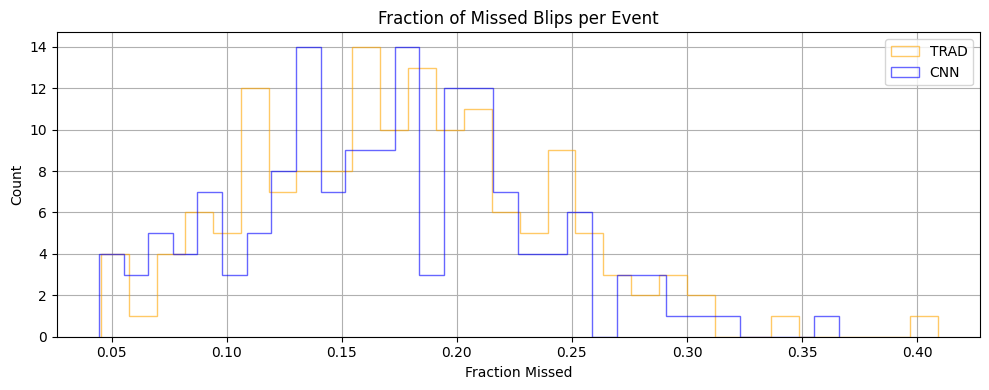

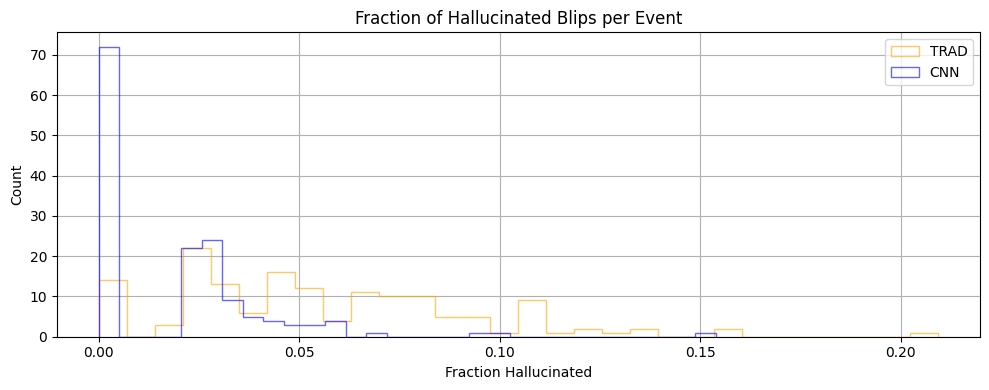

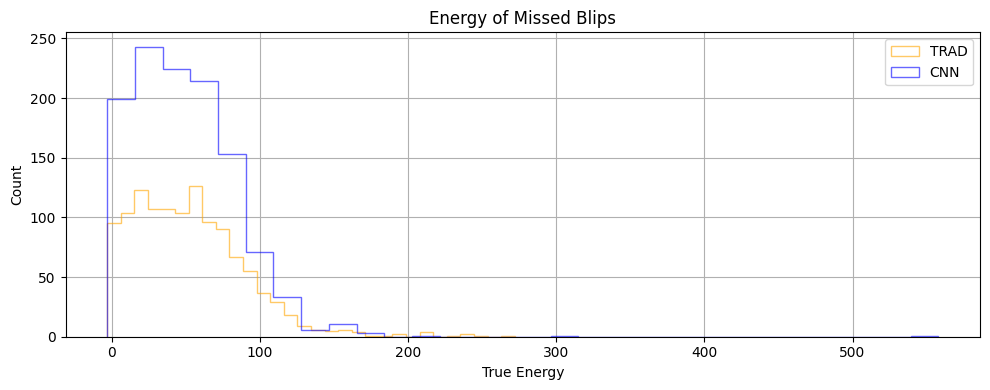

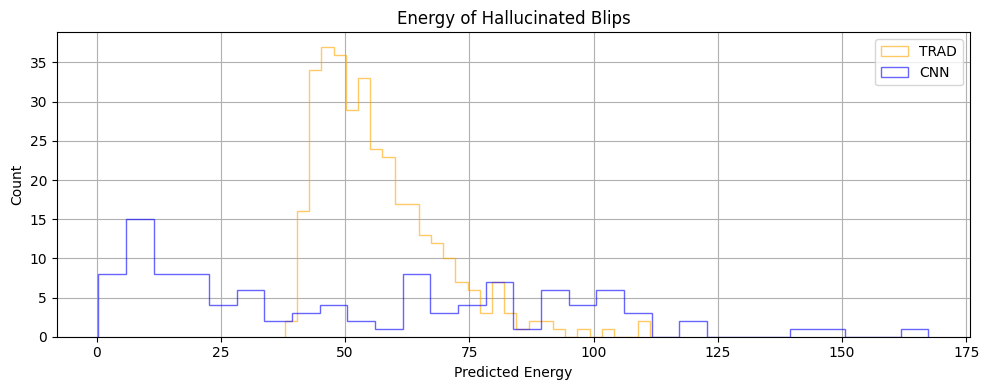

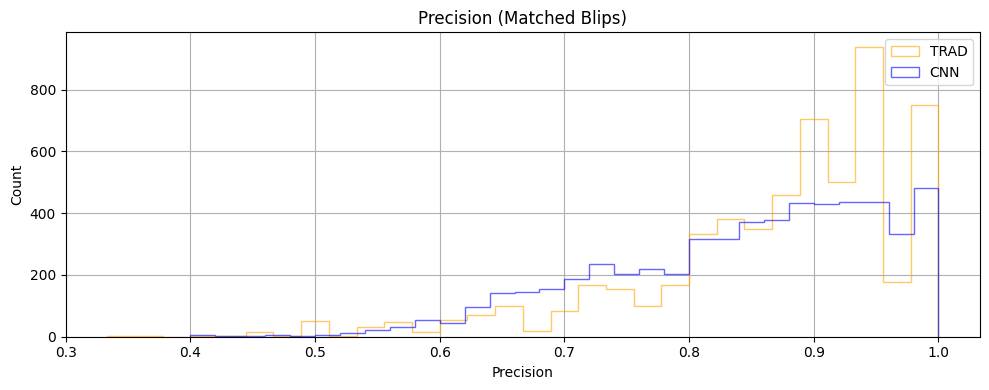

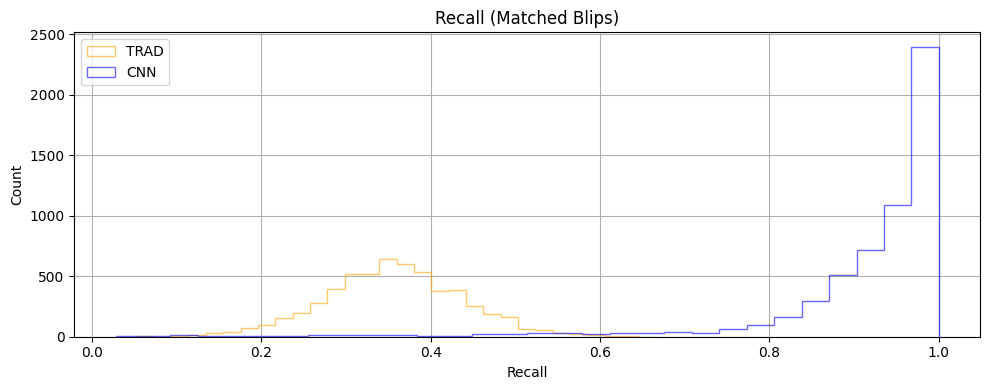

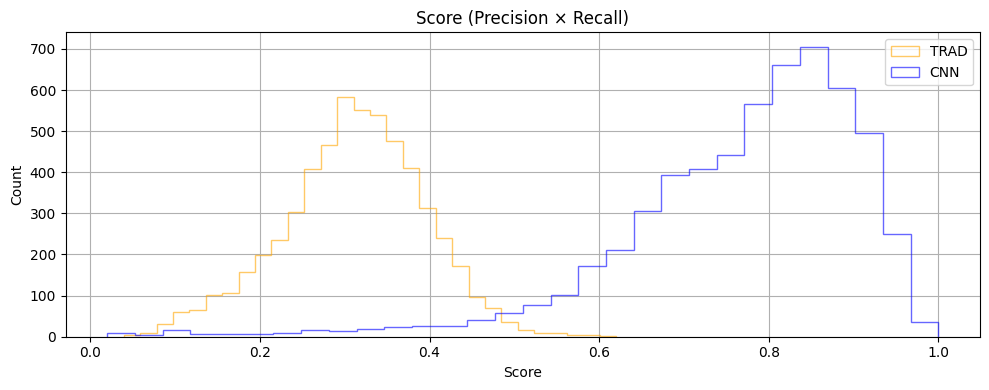

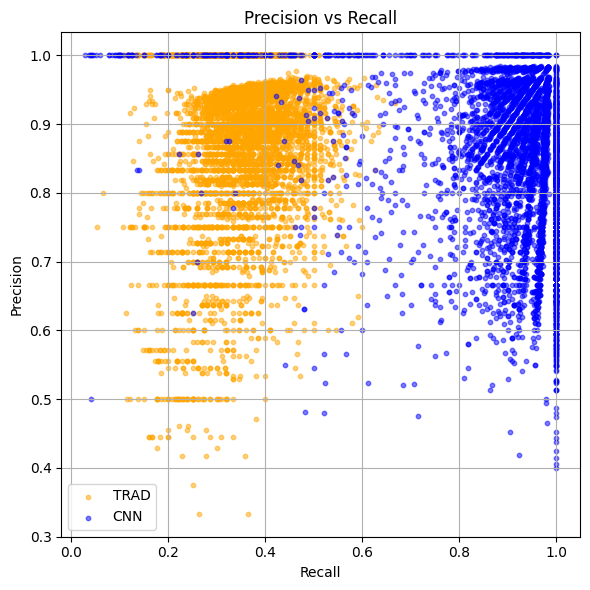

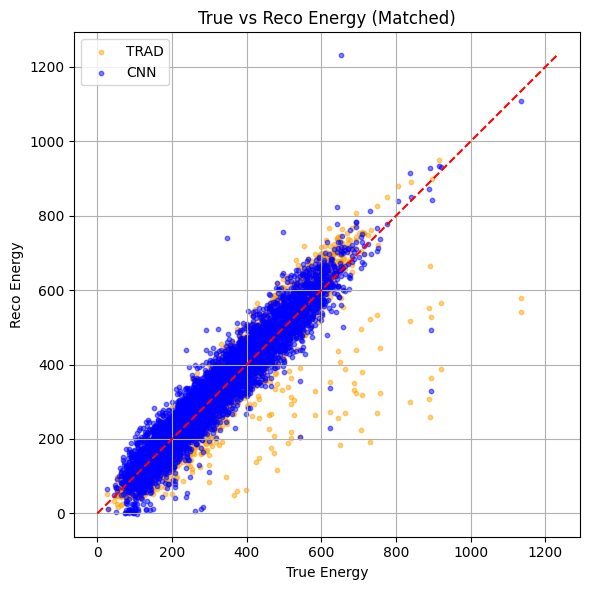

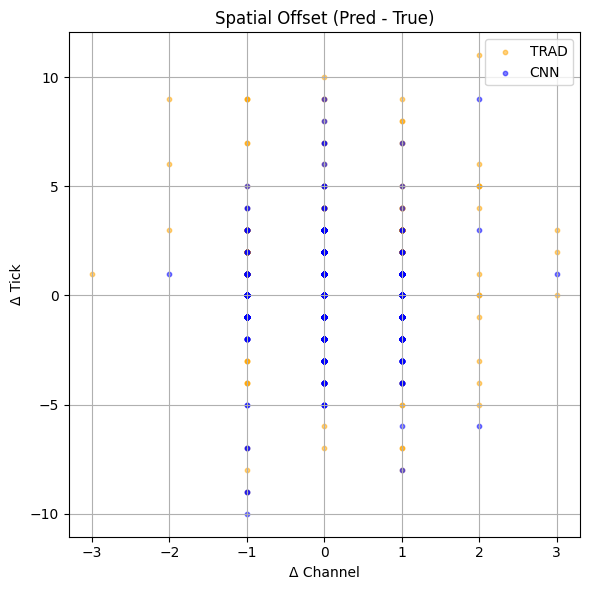

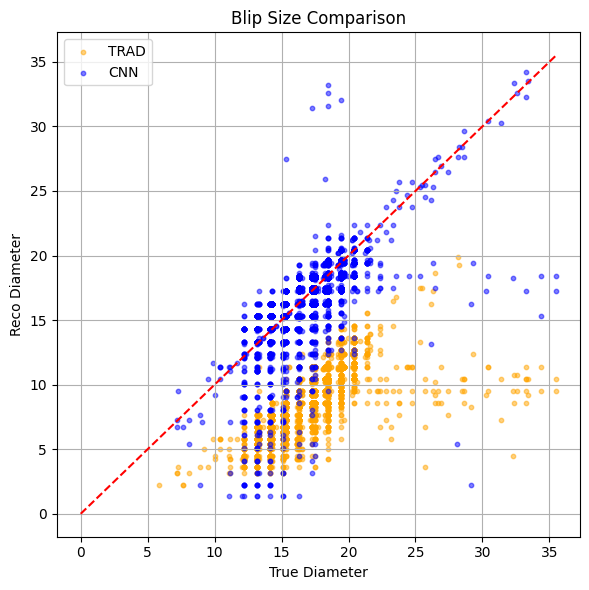

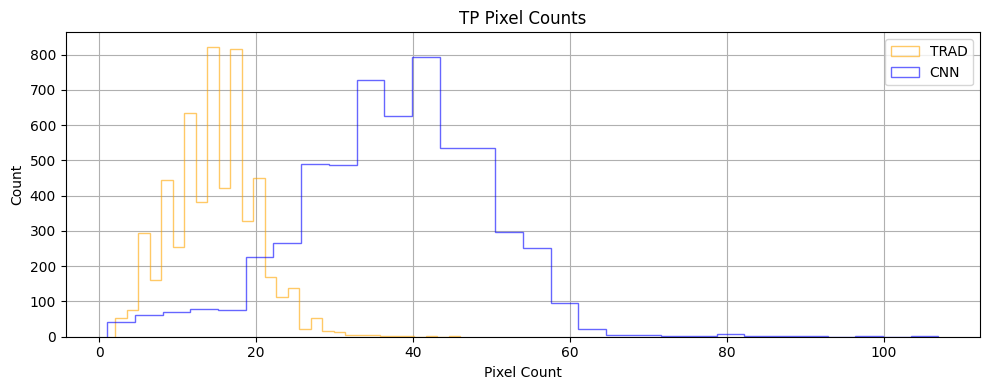

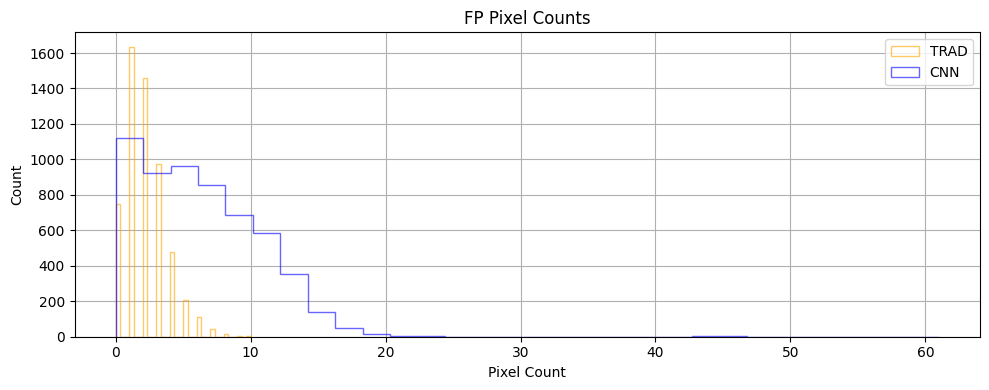

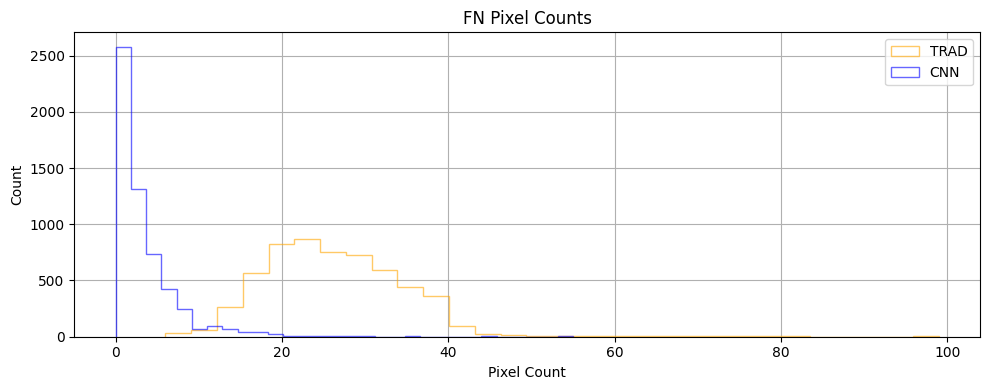

In [51]:
plot_blip_evaluation_diagnostics(results)